In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from utils import neural_utils as nu
from utils.callbacks import *

$-u_{xx} = f(x)$

$f(x) = (k\pi)^2\sin(k \pi x)$

$x \in [0,1]$

$u(0) = u(1) = 0$

solution: $u(x) = \sin(k \pi x)$

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed = 0

np.random.seed(seed)
torch.manual_seed(seed)

X_data = torch.tensor([0.0,1.0]).unsqueeze(1).to(device)
U_data = torch.tensor([0.0,0.0]).unsqueeze(1).to(device)



In [10]:
print(device)

cuda


In [11]:
def make_residual(k):
    def f(X, u, grad_U):
        u_xx = nu.gradients(grad_U, X)[:]
        return u_xx + (k * torch.pi)**2 * torch.sin(k * torch.pi * X)
    return f

f_1 = make_residual(1)

In [12]:
# loop over k need to add random fourier later
# use checkpointing callback in training loop
save_dir = r"C:\Users\victo\GitHub Projects\DiffEqML\demos\temp_saves"
os.makedirs(save_dir, exist_ok=True)

depth = 5
width = 50

k_value = [2, 8, 32, 128]
losses = {
    "model_t": [],
    "model_s": []
}
checkpoints = {
    "model_t": [],
    "model_s": []
}
spectrums = {
    "model_t": [],
    "model_s": []
}

epochs = 40000
N_col = 5000
N_spectrum = 512
X_col = torch.linspace(0, 1, N_col).unsqueeze(1).to(device)
Spatial_data = torch.linspace(0, 1, N_spectrum).unsqueeze(1).to(device)

for k in k_value:
    print(f"Training for k={k}...")
    
    f = make_residual(k)
    model_t = nu.FCN(1, 1, width, depth).to(device)
    model_s = nu.FCN(1, 1, width, depth, SIREN=True).to(device)

    optimizer_t = torch.optim.Adam(model_t.parameters(), lr=1e-4)
    optimizer_s = torch.optim.Adam(model_s.parameters(), lr=1e-4)

    callbacks_t = [LoggingCallback(log_interval=1000), 
                   CheckpointCallback(),
                   SaveTrajectoryCallback(save_interval=100, save_path=os.path.join(save_dir, f"trajectory_50_5_t_{k}.pt")), 
                   SpectrumCallback(Spatial_data, transform = torch.fft.rfft, save_interval=100)] 
    callbacks_s = [LoggingCallback(log_interval=1000), 
                   CheckpointCallback(),
                   SaveTrajectoryCallback(save_interval=100, save_path=os.path.join(save_dir, f"trajectory_50_5_s_{k}.pt")), 
                   SpectrumCallback(Spatial_data, transform = torch.fft.rfft, save_interval=100)]

    loss_t, data_loss_t, physics_loss_t, results_t = nu.train(
        epochs, optimizer_t, X_data, U_data, model_t, f, 1.0, X_col, callbacks=callbacks_t
    )
    loss_s, data_loss_s, physics_loss_s, results_s = nu.train(
        epochs, optimizer_s, X_data, U_data, model_s, f, 1.0, X_col, callbacks=callbacks_s
    )

    losses["model_t"].append((loss_t, physics_loss_t, data_loss_t))
    losses["model_s"].append((loss_s, physics_loss_s, data_loss_s))

    checkpoints["model_t"].append(results_t["CheckpointCallback"])
    checkpoints["model_s"].append(results_s["CheckpointCallback"])

    spectrums["model_t"].append(results_t["SpectrumCallback"])
    spectrums["model_s"].append(results_s["SpectrumCallback"])


    print(f"Finished training for k={k}. Total Loss: {loss_t[-1]:.4e} (tanh), {loss_s[-1]:.4e} (siren)")

torch.save(checkpoints, os.path.join(save_dir, "50_5_state.pt"))

torch.save(spectrums, os.path.join(save_dir, "50_5_spectrums.pt"))


Training for k=2...


Training:   3%|▎         | 1006/40000 [00:20<12:30, 51.99it/s]

Epoch   999 | Total Loss: 2.3142e+01 | Data Loss: 1.6207e+01 | Physics Loss: 6.9355e+00


Training:   5%|▌         | 2008/40000 [00:40<10:48, 58.57it/s]

Epoch  1999 | Total Loss: 1.1832e+01 | Data Loss: 1.0427e+01 | Physics Loss: 1.4048e+00


...

Training:  95%|█████████▌| 38005/40000 [12:46<00:41, 47.91it/s]

Epoch 37999 | Total Loss: 7.9553e+05 | Data Loss: 1.0356e+00 | Physics Loss: 7.9553e+05


Training:  98%|█████████▊| 39006/40000 [13:07<00:18, 53.21it/s]

Epoch 38999 | Total Loss: 7.8018e+05 | Data Loss: 8.9273e-01 | Physics Loss: 7.8018e+05


Epoch 39999 | Total Loss: 7.2246e+05 | Data Loss: 8.5069e-01 | Physics Loss: 7.2246e+05

[Callback] No save path provided. Spectra data not saved to disk.

[Callback] Successfully saved single trajectory file to: C:\Users\victo\GitHub Projects\DiffEqML\demos\temp_saves\trajectory_50_5_s_128.pt
Finished training for k=128. Total Loss: 1.2765e+10 (tanh), 7.2246e+05 (siren)


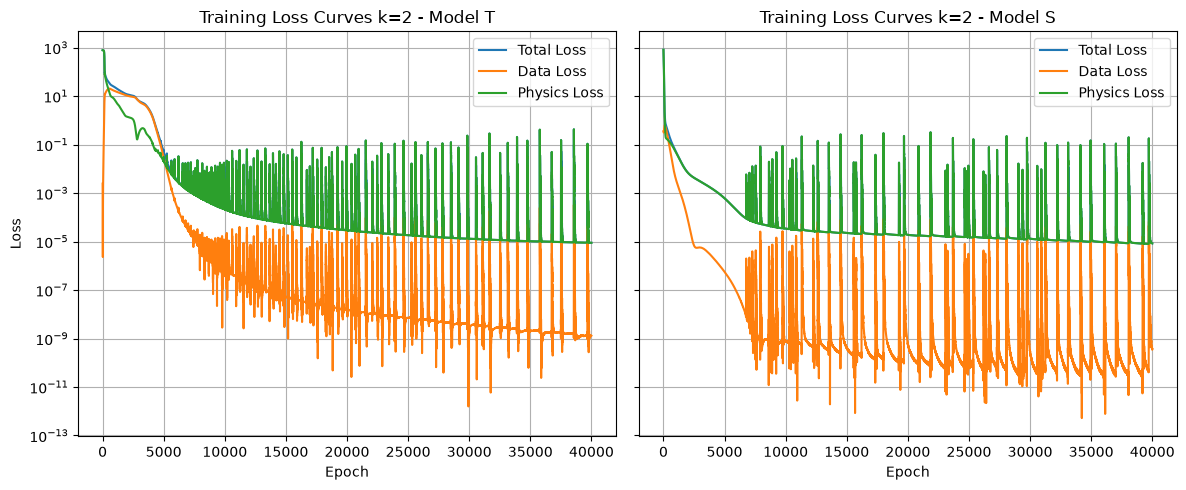

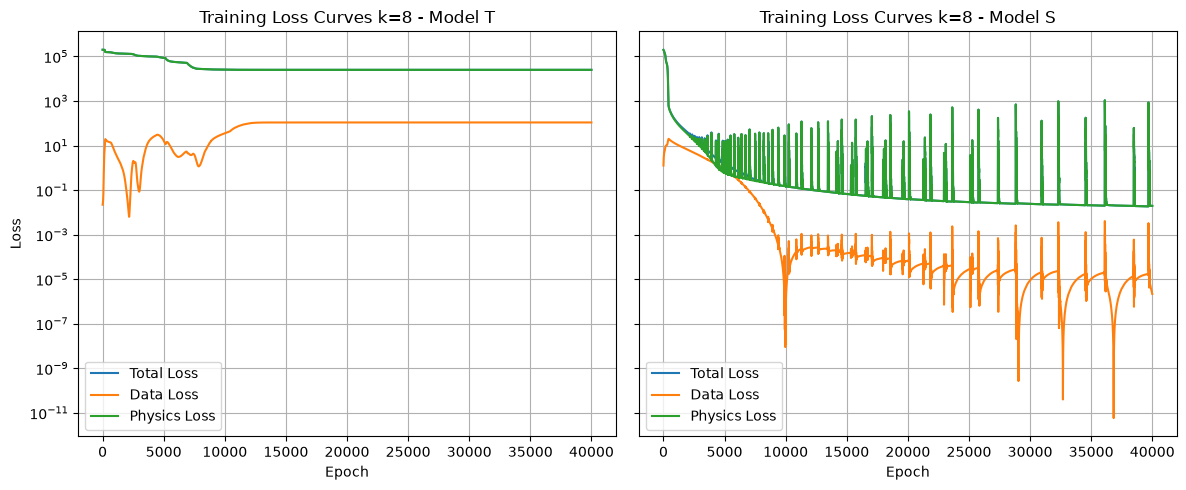

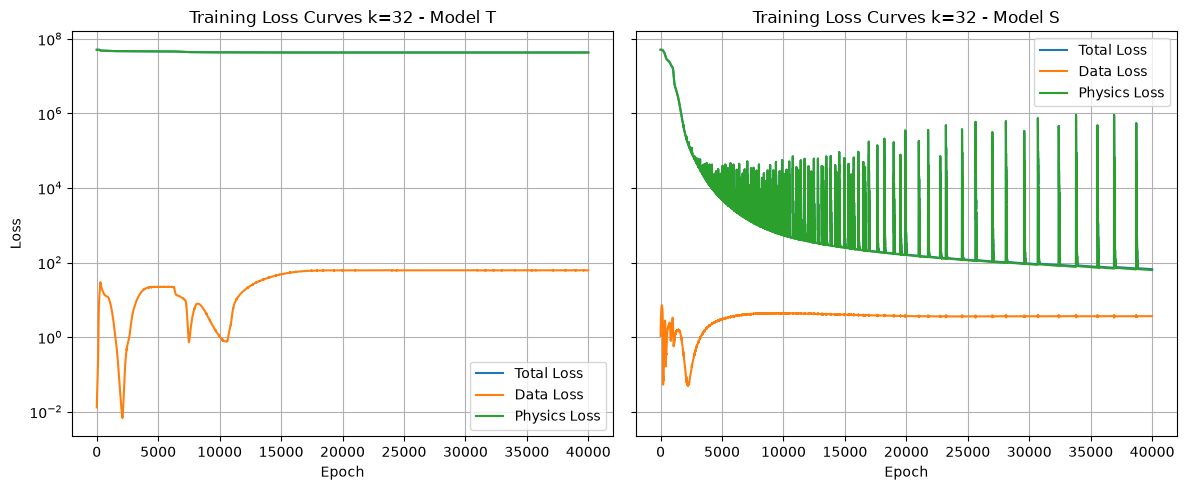

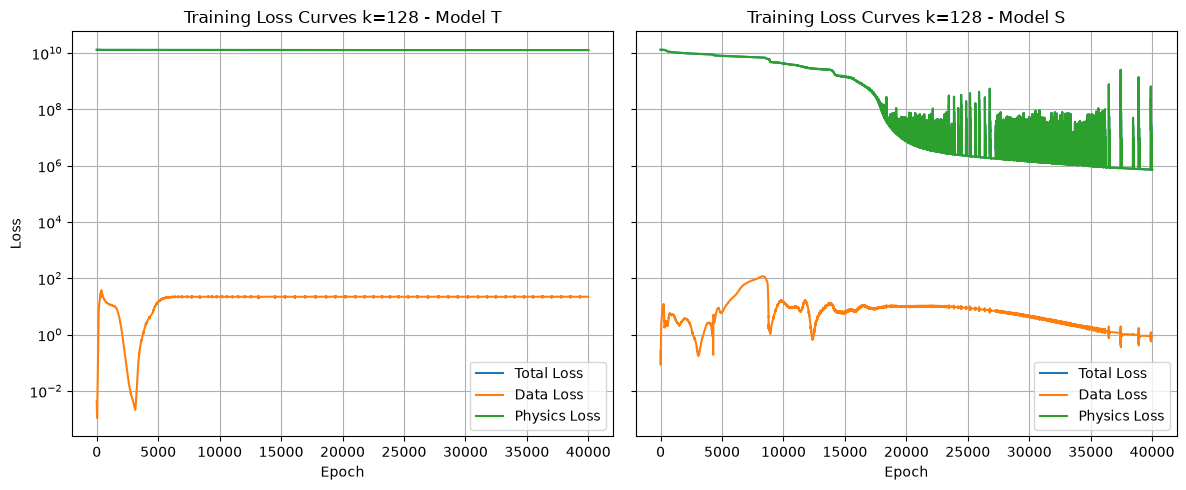

In [13]:
for i,k in enumerate(k_value):

    t_loss = losses["model_t"][i][0]
    t_data_loss = losses["model_t"][i][2]
    t_phys_loss = losses["model_t"][i][1]

    s_loss = losses["model_s"][i][0]
    s_data_loss = losses["model_s"][i][2]
    s_phys_loss = losses["model_s"][i][1]

    epochs = range(len(t_loss))

    fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    ax[0].plot(epochs, t_loss, label='Total Loss')
    ax[0].plot(epochs, t_data_loss, label='Data Loss')
    ax[0].plot(epochs, t_phys_loss, label='Physics Loss')

    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].set_title(f'Training Loss Curves k={k} - Model T')
    ax[0].set_yscale('log')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].plot(epochs, s_loss, label='Total Loss')
    ax[1].plot(epochs, s_data_loss, label='Data Loss')
    ax[1].plot(epochs, s_phys_loss, label='Physics Loss')

    ax[1].set_xlabel('Epoch')
    ax[1].set_title(f'Training Loss Curves k={k} - Model S')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()



In [14]:
type(checkpoints["model_t"])

list

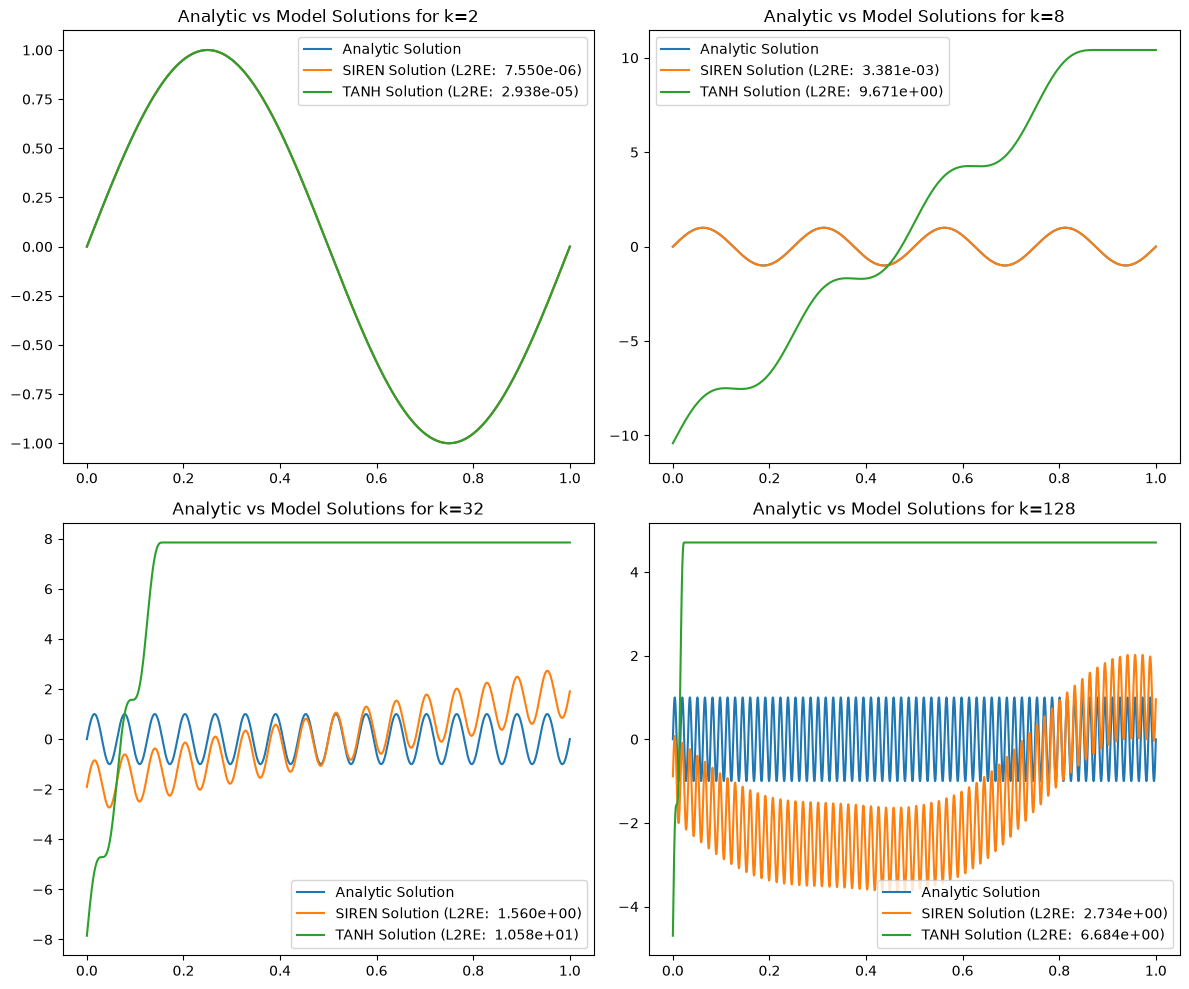

In [15]:
# Frequency domain analysis

from torch.fft import fft, ifft, rfft, fftfreq

# what sort of fourier compoonents can be extracted from model. is siren periodic 

# take DFT at collocation points as approximant of fourier spectrum

# analytic solution sin (k pi x)

# read chapter 2 of Spectral bias in physics-informed and operator learning: Analysis and mitigation guidelines

# metric to quantify spectral bias

# develop a regularization term that penalizes the model for not capturing high-frequency components


depth = 5
width = 50

models_t = {}
models_s = {}

analytic_solution = lambda x, k: torch.sin(k * torch.pi * x)

for k in k_value:
    model_t = nu.FCN(1, 1, width, depth).to('cpu')
    model_s = nu.FCN(1, 1, width, depth, SIREN=True).to('cpu')

    # checkpoints["model_t"][k_value.index(k)] is dict with keys epoch, model_state_dict, loss
    model_t.load_state_dict(checkpoints["model_t"][k_value.index(k)]["model_state_dict"])
    model_s.load_state_dict(checkpoints["model_s"][k_value.index(k)]["model_state_dict"])

    models_t[k] = model_t
    models_s[k] = model_s

fourier_analytic = {}
fourier_model = {}

fig, axes = plt.subplots(2,2, figsize=(12, 10))
axes_flat = axes.flatten()

for i in range(len(k_value)):
    k = k_value[i]

    model_s = models_s[k]
    model_t = models_t[k]

    N_plot = 10000
    plot_data = torch.linspace(0, 1, N_plot, device='cpu').unsqueeze(1)
    plot_sol = analytic_solution(plot_data, k=k)
    plot_t_sol = model_t(plot_data).detach()
    plot_s_sol = model_s(plot_data).detach()
    x_np = plot_data.squeeze().numpy()
    l2re_s = nu.L2RE(plot_s_sol, plot_sol)
    l2re_t = nu.L2RE(plot_t_sol, plot_sol)

    axes_flat[i].plot(x_np, plot_sol.numpy(), label='Analytic Solution')
    axes_flat[i].plot(x_np, plot_s_sol.numpy(), label=f'SIREN Solution (L2RE: {l2re_s: .3e})')
    axes_flat[i].plot(x_np, plot_t_sol.numpy(), label=f'TANH Solution (L2RE: {l2re_t: .3e})')

    axes_flat[i].set_title(f'Analytic vs Model Solutions for k={k}')
    axes_flat[i].legend()
    
plt.tight_layout()
plt.show()

torch.Size([1024, 1]) torch.Size([1024, 1]) torch.Size([1024, 1])
torch.Size([1024, 1]) torch.Size([1024, 1]) torch.Size([1024, 1])
torch.Size([1024, 1]) torch.Size([1024, 1]) torch.Size([1024, 1])
torch.Size([1024, 1]) torch.Size([1024, 1]) torch.Size([1024, 1])


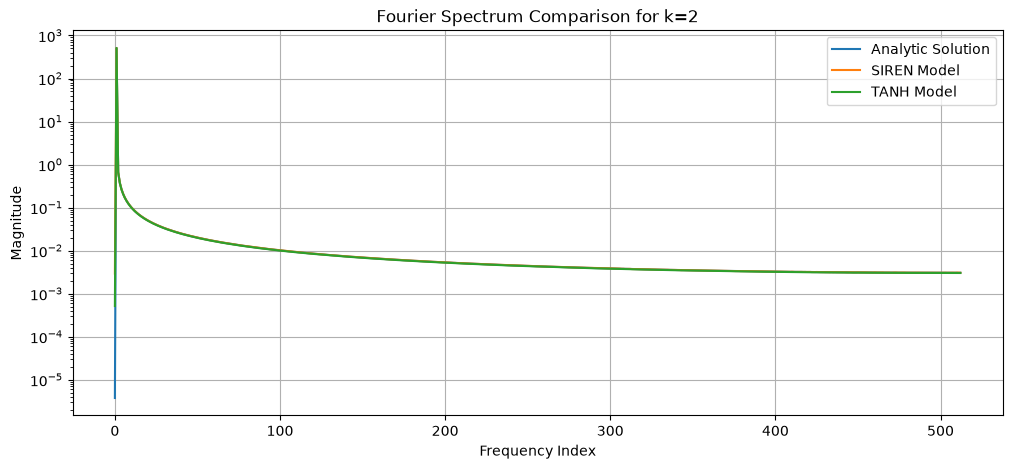

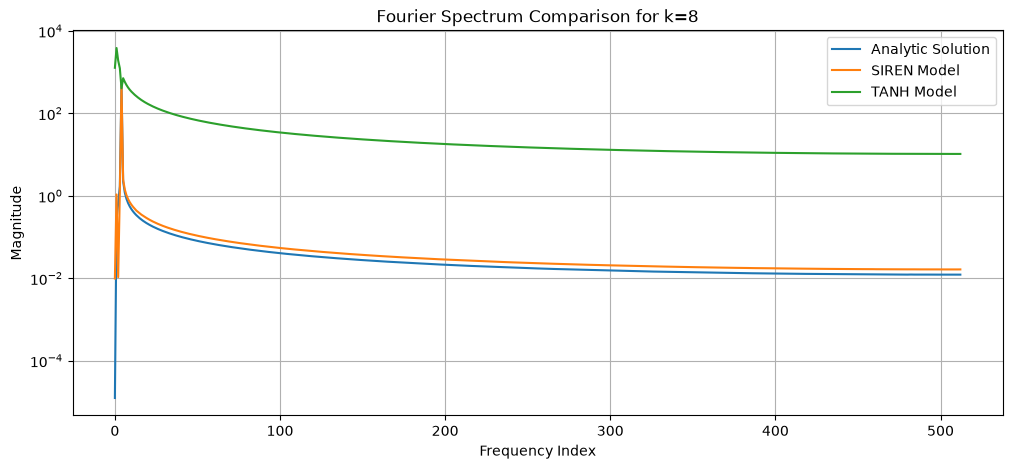

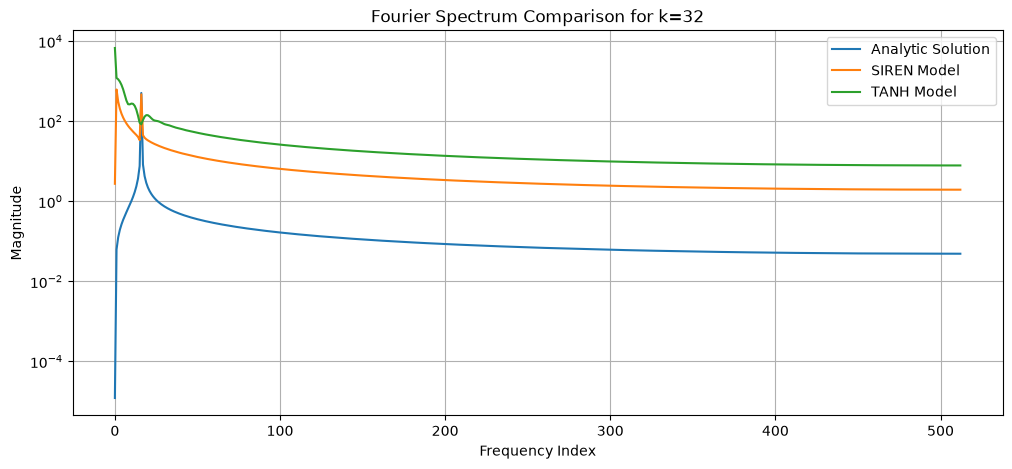

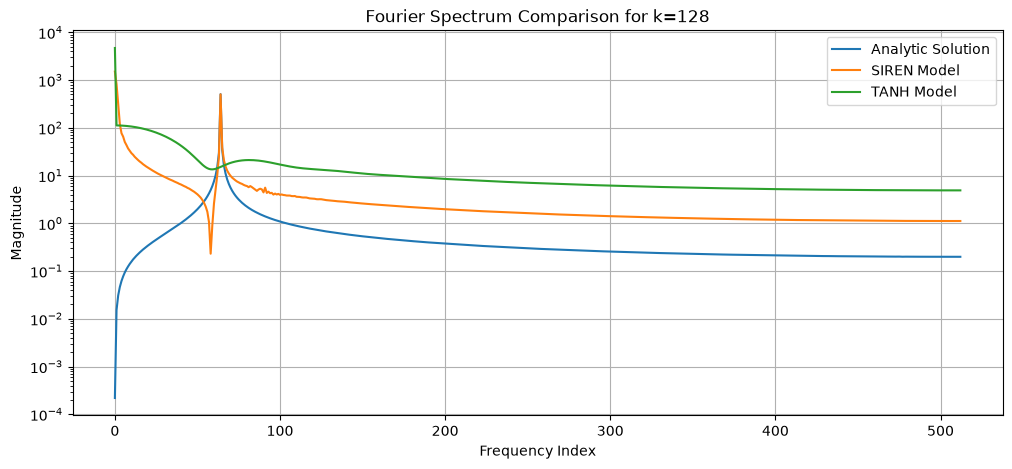

In [16]:
fourier_analytic = {}
fourier_model_s = {}
fourier_model_t = {}

for i in range(len(k_value)):
    N_data = 1024
    k = k_value[i]

    model_s = models_s[k]
    model_t = models_t[k]

    data = torch.linspace(0, 1, N_data).unsqueeze(1).to('cpu')
    sol = analytic_solution(data, k=k)

    model_s_sol = model_s(data).detach()
    model_t_sol = model_t(data).detach()

    print(model_s_sol.shape, model_t_sol.shape, sol.shape)
    fourier_analytic[k] = rfft(sol, dim=0).squeeze(-1)
    fourier_model_s[k] = rfft(model_s_sol, dim=0).squeeze(-1)
    fourier_model_t[k] = rfft(model_t_sol, dim=0).squeeze(-1)

for i in range(len(k_value)):
    k = k_value[i]

    plt.figure(figsize=(12, 5))
    plt.plot(fourier_analytic[k].abs().numpy(), label='Analytic Solution')
    plt.plot(fourier_model_s[k].abs().numpy(), label='SIREN Model')
    plt.plot(fourier_model_t[k].abs().numpy(), label='TANH Model')

    plt.title(f'Fourier Spectrum Comparison for k={k}')
    plt.xlabel('Frequency Index')
    plt.ylabel('Magnitude')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()